In [1]:
import numpy as np
from scr.nb_helper_functions import to_chunks
from scr.nb import NB_predictions, adjust_nb_predictions, visualize_predictions
from scr.validation_helpers import get_train_sample, get_nb_model
import matplotlib.pyplot as plt
import joblib

In [2]:
samples= get_train_sample(10)
images = np.array(samples["image"])

Using the latest cached version of the dataset since shenandoah-macroinvertebrates/ept-bioassessment-dataset couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/wilsonbeima/.cache/huggingface/datasets/shenandoah-macroinvertebrates___ept-bioassessment-dataset/default/0.0.0/9823ae8352792361e66545658a29afc8abacd86c (last modified on Sun Mar 15 13:53:48 2026).


In [5]:
try:
    model = joblib.load("models/naive_bayes_model_2.pkl")
except FileNotFoundError:
    raise NotImplementedError("Please provide a model at models/naive_bayes_model.pkl")

In [6]:
subimages, predictions, shape = NB_predictions(images, model, slice_factor=1)

convoluting transpositions: 100%|██████████████████| 10/10 [00:16<00:00,  1.69s/it]


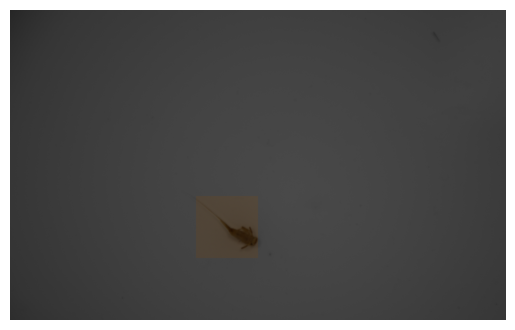

Should this be relabelled?(y/n)   9/10 n


In [7]:
corrected_predictions = adjust_nb_predictions(subimages, predictions, shape)

In [8]:
print(corrected_predictions)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1.
  0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [9]:
nb_specimens = subimages[0][predictions[0] == 1]